# Telco Customer Churn Analysis

Анализ оттока клиентов телеком-компании на основе публичного датасета Telco Customer Churn (https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data).

## Цель проекта
Выявить характеристики и сегменты клиентов, связанные с повышенным уровнем оттока, и сформулировать практические рекомендации, которые могут помочь компании снизить уровень оттока клиентов.

## Задачи
1. Понять, какие сегменты клиентов имеют наиболее высокий уровень оттока.
2. Определить, какие услуги, характеристики клиентов и условия контракта связаны с повышенным churn.
3. Проверить статистическую значимость наиболее заметных различий между ушедшими и оставшимися клиентами.
4. Сформулировать рекомендации по удержанию клиентов на основе результатов анализа.
5. Дополнительно провести SQL-анализ основных показателей

## Ключевые результаты
- **26,5%** - общий уровень оттока клиентов
- **47,4%** - уровень оттока среди клиентов со сроком обслуживания менее 1 года
- **42,7%** - уровень оттока клиентов с контрактом с ежемесячной оплатой
- **2,8%** - уровень оттока клиентов с двухлетним контрактом
- **41,9%** - уровень оттока среди клиентов с Fiber optic
- **54,6%** - уровень оттока в наиболее проблемном из выявленных сегментов Month-to-month + Fiber optic
- **Более 41%** - уровень оттока среди клиентов без OnlineSecurity и TechSupport.

## Что сделано
- Разведочный анализ (EDA) по демографии, услугам, контрактам и платежам
- Статистическая проверка гипотез (хи-квадрат, критерий Манна–Уитни)
- Анализ сочетаний признаков
- Практические рекомендации и ограничения анализа
- SQL-анализ основных показателей

## Стек
Python, pandas, matplotlib, seaborn, scipy, SQL (DuckDB)

## Содержание
1. Описание данных
2. Подготовка данных
3. EDA
4. Статистические проверки
5. Анализ сочетаний
6. Выводы и рекомендации
7. SQL - анализ

# Описание данных

Датасет содержит информацию о клиентах телекоммуникационной компании и их подключённых услугах. Каждая строка соответствует одному клиенту и включает сведения о его демографических характеристиках, сроке обслуживания, подключённых услугах, типе контракта, способе оплаты и расходах.

Ключевая переменная Churn показывает, прекратил ли клиент пользоваться услугами компании. Таким образом, датасет позволяет исследовать особенности клиентов, которые ушли, и сравнить их с клиентами, которые продолжают пользоваться услугами.

## Описание колонок:

customerID - уникальный ID клиента

gender - пол клиента (Male / Female)

SeniorCitizen - является ли клиент пенсионером (1 = да, 0 = нет)

Partner - есть ли у клиента партнёр (Yes / No)

Dependents - есть ли иждивенцы (дети и т.п.) (Yes / No)

tenure - сколько месяцев клиент уже пользуется услугами компании

PhoneService - подключена ли телефонная связь (Yes / No)

MultipleLines - есть ли несколько телефонных линий (Yes / No / No phone service)

InternetService - тип интернета (DSL / Fiber optic / No)

OnlineSecurity - есть ли услуга онлайн-безопасности (Yes / No / No internet service)

OnlineBackup - есть ли облачный бэкап (Yes / No / No internet service)

DeviceProtection - есть ли защита устройств (Yes / No / No internet service)

TechSupport - есть ли техническая поддержка (Yes / No / No internet service)

StreamingTV - есть ли стриминговое ТВ (Yes / No / No internet service)

StreamingMovies - есть ли стриминг фильмов (Yes / No / No internet service)

Contract - тип контракта (Month-to-month / One year / Two year)

PaperlessBilling - электронные счета (Yes / No)

PaymentMethod - способ оплаты (Electronic check, Mailed check, Bank transfer, Credit card)

MonthlyCharges - ежемесячный платёж

TotalCharges - общая сумма, которую клиент заплатил за всё время

Churn - ушёл ли клиент (Yes / No) - целевая переменная

# Подготовка данных

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub


pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Загрузка

In [2]:
path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn",
    output_dir="./data"
)

print(path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
/kaggle/input/telco-customer-churn


In [3]:
df = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.shape

(7043, 21)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Убираем лишние пробелы в строковых значениях
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# Проверяем пустые строки
(df == '').sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
# Уникальные значения TotalCharges, которые не удаётся интерпретировать как число
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')

total_charges_numeric.isna().sum()

np.int64(11)

In [9]:
df.loc[total_charges_numeric.isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [10]:
df[df['tenure'] == 0][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'Churn']]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


При проверке типов данных обнаружено, что `TotalCharges` имеет тип `object`, хотя содержит сумму платежей и должен быть числовым. После преобразования значений в числовой формат обнаружено 11 пустых значений. Все они относятся к клиентам с `tenure = 0`, то есть к клиентам, которые только начали пользоваться услугами компании.

In [11]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [12]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [13]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [14]:
df['TotalCharges'].dtype

dtype('float64')

`TotalCharges` преобразован в числовой тип. Пустые значения для 11 клиентов с `tenure = 0` заменены на 0.

In [15]:
df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


Числовые признаки находятся в ожидаемых диапазонах. Некорректных отрицательных значений и значений, выходящих за логические границы признаков, не обнаружено.

In [16]:
# Проверка на дубликаты
df.duplicated().sum()

np.int64(0)

# EDA

In [17]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [18]:
churn_share = (df['Churn'].value_counts(normalize=True) * 100).round(2)
churn_share

,proportion
Churn,
No,73.46
Yes,26.54


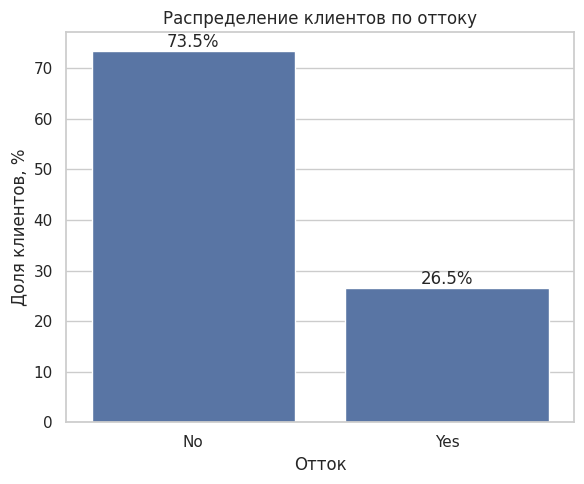

In [19]:
plt.figure(figsize=(6, 5))

ax = sns.barplot(
    x=churn_share.index,
    y=churn_share.values
)

ax.set_title('Распределение клиентов по оттоку')
ax.set_xlabel('Отток')
ax.set_ylabel('Доля клиентов, %')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Общий уровень оттока клиентов составляет 26,54%. Большинство клиентов (73,46%) продолжают пользоваться услугами компании. Далее необходимо определить, какие характеристики и условия обслуживания связаны с более высоким уровнем оттока.

После оценки общего уровня оттока рассмотрим, как он различается между группами клиентов. Для этого признаки разделим на несколько смысловых групп: демографические характеристики, подключённые услуги, условия контракта и оплаты, а также срок обслуживания и расходы.

In [20]:
demographic_columns = ['SeniorCitizen', 'gender', 'Partner', 'Dependents']

for col in demographic_columns:
    print(f'\n{col}')

    result = df.groupby(col)['Churn'].agg(
        clients='count',
        churned=lambda x: (x == 'Yes').sum(),
        churn_rate=lambda x: ((x == 'Yes').mean() * 100).round(2)
    )

    print(result)


SeniorCitizen
               clients  churned  churn_rate
SeniorCitizen                              
0                 5901     1393       23.61
1                 1142      476       41.68

gender
        clients  churned  churn_rate
gender                              
Female     3488      939       26.92
Male       3555      930       26.16

Partner
         clients  churned  churn_rate
Partner                              
No          3641     1200       32.96
Yes         3402      669       19.66

Dependents
            clients  churned  churn_rate
Dependents                              
No             4933     1543       31.28
Yes            2110      326       15.45


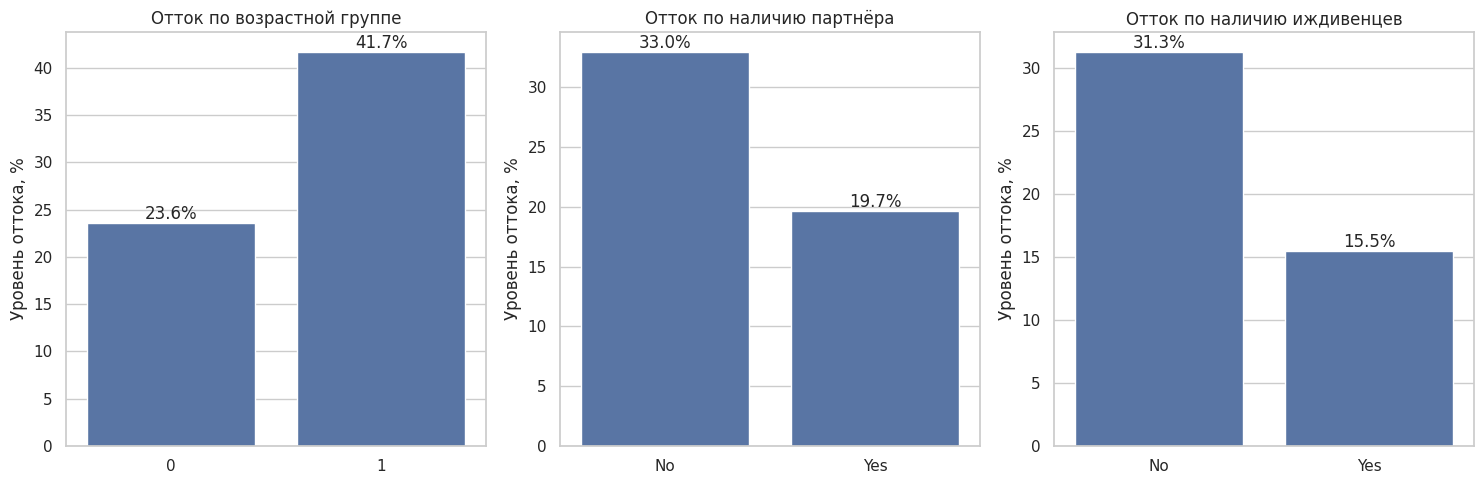

In [21]:
demographic_columns = ['SeniorCitizen', 'Partner', 'Dependents']

titles = {
    'SeniorCitizen': 'Отток по возрастной группе',
    'Partner': 'Отток по наличию партнёра',
    'Dependents': 'Отток по наличию иждивенцев'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(demographic_columns):
    churn_by_group = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='churn_rate')
    )

    sns.barplot(
        data=churn_by_group,
        x=col,
        y='churn_rate',
        ax=axes[i]
    )

    axes[i].set_title(titles[col])
    axes[i].set_ylabel('Уровень оттока, %')
    axes[i].set_xlabel('')

    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

Наиболее выраженные различия наблюдаются по признакам `SeniorCitizen`, `Partner` и `Dependents`:

* Среди клиентов старшей возрастной категории уровень оттока составляет **41,7% против 23,6%** у остальных клиентов.
* Клиенты без партнёра уходят чаще: **33,0% против 19,7%**.
* Клиенты без иждивенцев также показывают более высокий уровень оттока: **31,3% против 15,5%**.

Пол практически не связан с различиями в оттоке: разница между женщинами и мужчинами составляет менее 1 п.п. Поэтому `gender` не относится к признакам с заметными различиями и не является приоритетным для дальнейшего анализа.

Таким образом, в демографической группе наиболее заметные различия связаны с возрастной категорией, наличием партнёра и иждивенцев. Эти признаки стоит учитывать в дальнейшем анализе.

Далее проверим, как с оттоком связаны подключённые услуги.


In [22]:
service_columns = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_columns:
    print(f'\n{col}')

    result = df.groupby(col)['Churn'].agg(
        clients='count',
        churned=lambda x: (x == 'Yes').sum(),
        churn_rate=lambda x: (x == 'Yes').mean() * 100
    )

    print(result)


PhoneService
              clients  churned  churn_rate
PhoneService                              
No                682      170   24.926686
Yes              6361     1699   26.709637

MultipleLines
                  clients  churned  churn_rate
MultipleLines                                 
No                   3390      849   25.044248
No phone service      682      170   24.926686
Yes                  2971      850   28.609896

InternetService
                 clients  churned  churn_rate
InternetService                              
DSL                 2421      459   18.959108
Fiber optic         3096     1297   41.892765
No                  1526      113    7.404980

OnlineSecurity
                     clients  churned  churn_rate
OnlineSecurity                                   
No                      3498     1461   41.766724
No internet service     1526      113    7.404980
Yes                     2019      295   14.611194

OnlineBackup
                     clients  churned

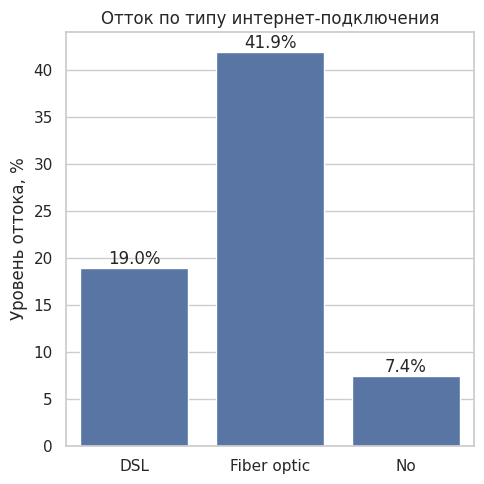

In [23]:
internet_columns = ['InternetService']

titles = {
    'InternetService': 'Отток по типу интернет-подключения'
}

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

churn_by_group = (
    df.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

sns.barplot(
    data=churn_by_group,
    x='InternetService',
    y='churn_rate',
    ax=axes
)

axes.set_title(titles['InternetService'])
axes.set_ylabel('Уровень оттока, %')
axes.set_xlabel('')

for p in axes.patches:
    height = p.get_height()
    axes.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Уровень оттока заметно различается в зависимости от `InternetService`:

* Fiber optic - 41,9%
* DSL - 19,0%
* Нет интернета - 7,4%

Наиболее высокий уровень оттока наблюдается среди клиентов с подключением Fiber optic - **41,9%**. Это одно из наиболее заметных различий в текущем анализе.




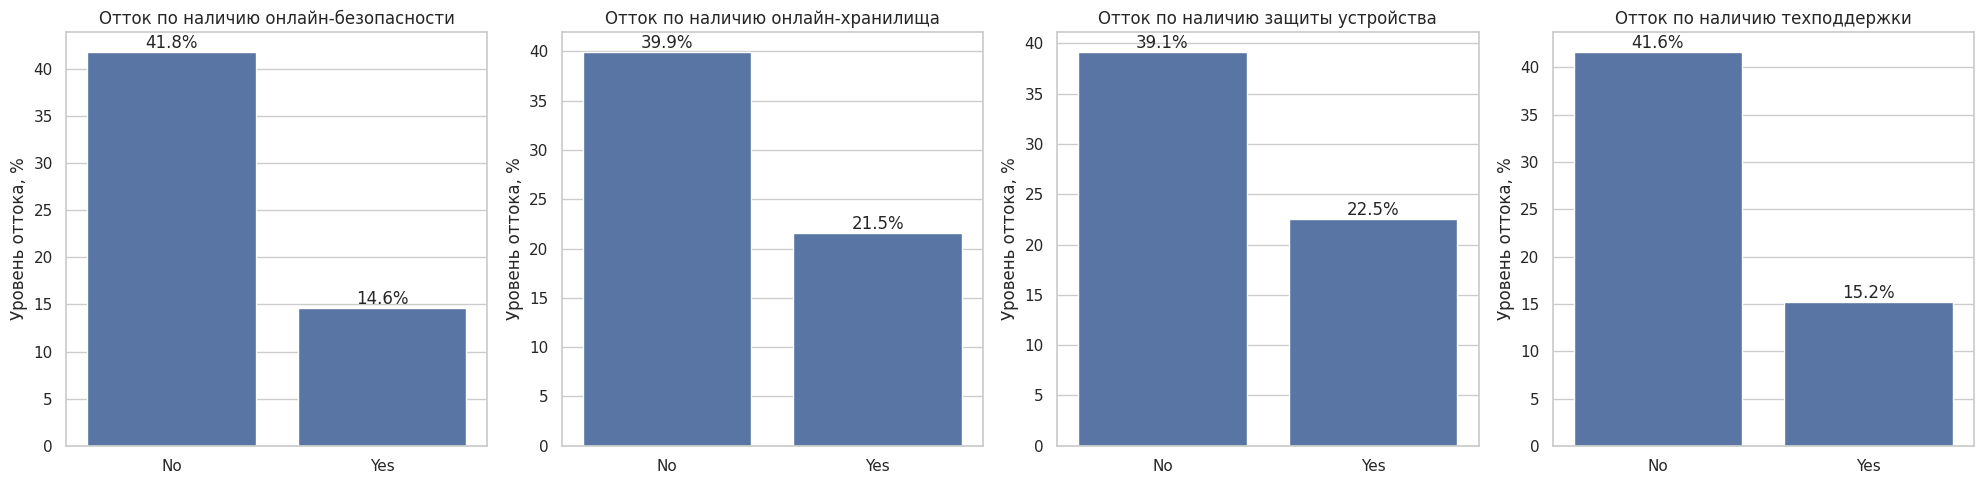

In [24]:
internet_service_columns = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport'
]

titles = {
    'OnlineSecurity': 'Отток по наличию онлайн-безопасности',
    'OnlineBackup': 'Отток по наличию онлайн-хранилища',
    'DeviceProtection': 'Отток по наличию защиты устройства',
    'TechSupport': 'Отток по наличию техподдержки'
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(internet_service_columns):

    # Оставляем только клиентов, у которых есть интернет
    filtered_df = df[df['InternetService'] != 'No']

    churn_by_group = (
        filtered_df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='churn_rate')
    )

    sns.barplot(
        data=churn_by_group,
        x=col,
        y='churn_rate',
        ax=axes[i]
    )

    axes[i].set_title(titles[col])
    axes[i].set_ylabel('Уровень оттока, %')
    axes[i].set_xlabel('')

    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

Наличие дополнительных услуг связано с более низким уровнем оттока:

* `OnlineSecurity` - **41,8% без услуги** против 14,6% с услугой
* `TechSupport` - **41,6% без услуги** против 15,2% с услугой
* `OnlineBackup` - **39,9% без услуги** против 21,5% с услугой
* `DeviceProtection` - **39,1% без услуги** против 22,5% с услугой

Анализ проводился только среди клиентов, у которых есть интернет.

Наиболее выраженные различия наблюдаются для `OnlineSecurity` и `TechSupport`.


Далее блок «Контракт и оплата». Здесь нужно проверить, связан ли отток с условиями договора и способом оплаты.

In [25]:
contract_columns = ['Contract', 'PaperlessBilling', 'PaymentMethod']

for col in contract_columns:
    print(f'\n{col}')

    result = df.groupby(col)['Churn'].agg(
        clients='count',
        churned=lambda x: (x == 'Yes').sum(),
        churn_rate=lambda x: (x == 'Yes').mean() * 100
    )

    print(result)


Contract
                clients  churned  churn_rate
Contract                                    
Month-to-month     3875     1655   42.709677
One year           1473      166   11.269518
Two year           1695       48    2.831858

PaperlessBilling
                  clients  churned  churn_rate
PaperlessBilling                              
No                   2872      469   16.330084
Yes                  4171     1400   33.565092

PaymentMethod
                           clients  churned  churn_rate
PaymentMethod                                          
Bank transfer (automatic)     1544      258   16.709845
Credit card (automatic)       1522      232   15.243101
Electronic check              2365     1071   45.285412
Mailed check                  1612      308   19.106700


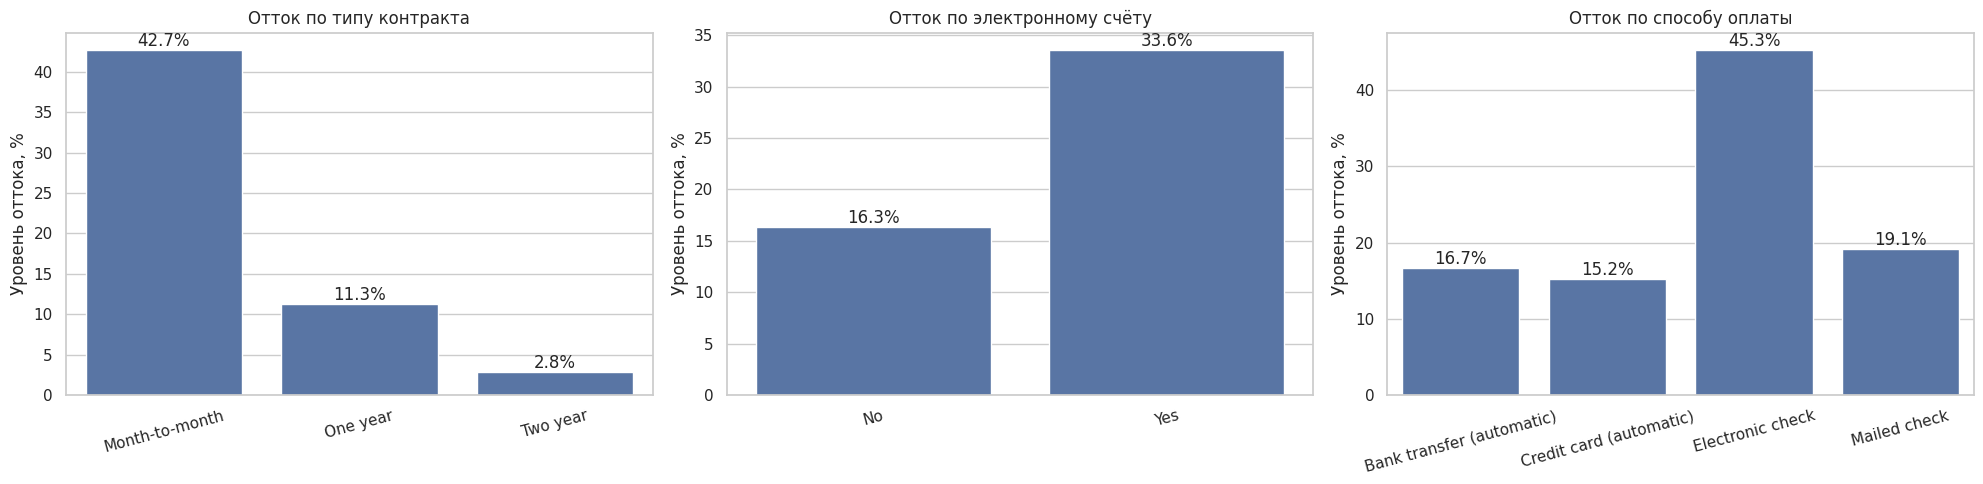

In [26]:
contract_columns = [
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

titles = {
    'Contract': 'Отток по типу контракта',
    'PaperlessBilling': 'Отток по электронному счёту',
    'PaymentMethod': 'Отток по способу оплаты'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(contract_columns):
    churn_by_group = (
        df.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .reset_index(name='churn_rate')
    )

    sns.barplot(
        data=churn_by_group,
        x=col,
        y='churn_rate',
        ax=axes[i]
    )

    axes[i].set_title(titles[col])
    axes[i].set_ylabel('Уровень оттока, %')
    axes[i].set_xlabel('')

    axes[i].tick_params(axis='x', rotation=15)

    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

`Contract` показывает одно из наиболее заметных различий:

* Month-to-month - **42,7%**
* One year - **11,3%**
* Two year - **2,8%**

Уровень оттока среди клиентов с ежемесячным контрактом примерно в 15 раз выше, чем среди клиентов с двухлетним контрактом.

`PaymentMethod`:

* Electronic check - **45,3%** - самый высокий показатель среди способов оплаты;
* остальные способы оплаты - **15,2-19,1%**.

Получение счёта в электронном виде (`PaperlessBilling`):

* Да - **33,6%**
* Нет - **16,3%**

Разница заметная, но меньше, чем для типа контракта и способа оплаты Electronic check.


Далее проведем анализ по сроку обслуживания (`tenure`) и расходам.

Для анализа срока обслуживания разделим данные на группы: "до года", "1-2 года", "2-4 года" и "4-6 лет"

In [27]:
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = [
    'До 1 года',
    '1–2 года',
    '2–4 года',
    '4–6 лет'
]

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

In [28]:
tenure_churn = (
    df.groupby('tenure_group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

tenure_churn

,tenure_group,churn_rate
0,До 1 года,47.438243
1,1–2 года,28.710938
2,2–4 года,20.388959
3,4–6 лет,9.513176


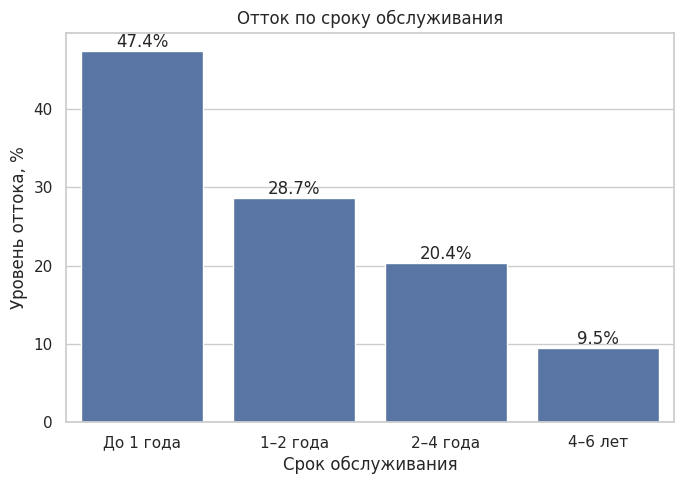

In [29]:
tenure_churn = (
    df.groupby('tenure_group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=tenure_churn,
    x='tenure_group',
    y='churn_rate'
)

plt.title('Отток по сроку обслуживания')
plt.xlabel('Срок обслуживания')
plt.ylabel('Уровень оттока, %')

for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Уровень оттока заметно снижается с увеличением срока обслуживания:

* до 1 года - 47,4%;
* 1-2 года - 28,7%;
* 2-4 года - 20,4%;
* 4-6 лет - 9,5%.

Наиболее высокий уровень оттока наблюдается среди новых клиентов - почти половина клиентов со сроком обслуживания до года ушла. Среди клиентов, которые пользуются услугами более четырёх лет, отток составляет менее 10%.


In [30]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


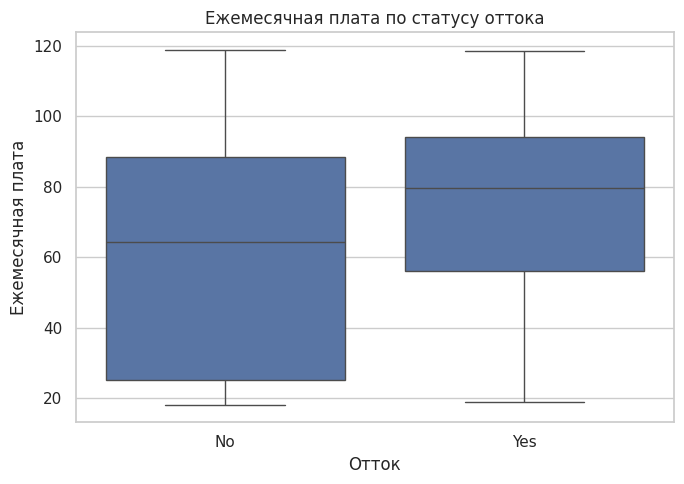

In [31]:
plt.figure(figsize=(7, 5))

ax = sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)

ax.set_title('Ежемесячная плата по статусу оттока')
ax.set_xlabel('Отток')
ax.set_ylabel('Ежемесячная плата')

plt.tight_layout()
plt.show()

У клиентов, которые ушли, ежемесячная плата выше:

* оставшиеся клиенты - 61,3;
* ушедшие клиенты - 74,4.

Медианная плата также выше у ушедших клиентов: 79,65 против 64,43.

Таким образом, `MonthlyCharges` различается между ушедшими и оставшимися клиентами.

По результатам EDA можно выделить несколько характеристик, связанных с более высоким уровнем оттока клиентов.

Наиболее заметные различия наблюдаются по сроку обслуживания, типу контракта, типу интернет-подключения, дополнительным интернет-услугам и размеру ежемесячной платы.

- У новых клиентов отток значительно выше: среди клиентов со сроком обслуживания до года он составляет 47,4%, а для клиентов со сроком обслуживания более четырёх лет - 9,5%.

- Существенные различия наблюдаются и для типа контракта. У клиентов с ежемесячным контрактом уровень оттока составляет 42,7%, с контрактом на один год - 11,3%, а на два года - 2,8%.

- Среди типов интернет-подключения наиболее высокий уровень оттока наблюдается у клиентов с Fiber optic - 41,9%. Для DSL показатель составляет 19,0%, а среди клиентов без интернета - 7,4%.

- Среди клиентов с интернетом заметные различия также наблюдаются для дополнительных услуг. Например, уровень оттока составляет 41,8% у клиентов без OnlineSecurity и 14,6% у клиентов с этой услугой. Для TechSupport показатели составляют 41,6% и 15,2% соответственно.

- У ушедших клиентов также выше ежемесячная плата: среднее значение составляет 74,44 против 61,27 у оставшихся клиентов.

При этом результаты EDA показывают связь между признаками и оттоком, но не доказывают причинно-следственную зависимость. Например, высокий уровень оттока среди клиентов с ежемесячным контрактом не означает, что именно тип контракта является причиной ухода.

Следующий этап анализа - статистически проверить наиболее заметные различия и определить, какие из них являются статистически значимыми.

# Статистические проверки

На этапе EDA были выявлены признаки, для которых наблюдаются заметные различия в уровне оттока.

На этом этапе проверим, являются ли эти различия статистически значимыми или они могли возникнуть случайно.

Для категориальных признаков будем использовать критерий хи-квадрат, а для числовых признаков - критерий Манна-Уитни.

## Связь типа контракта и оттока

В EDA было обнаружено заметное различие в уровне оттока между клиентами с разными типами контрактов.

Проверим, существует ли статистически значимая связь между типом контракта (`Contract`) и оттоком клиентов (`Churn`).

**Гипотезы.**

**H₀:** тип контракта и отток клиентов независимы.

**H₁:** между типом контракта и оттоком клиентов существует статистически значимая связь.

Для проверки используем критерий хи-квадрат независимости, поскольку обе переменные являются категориальными.

In [34]:
# строим таблицу сопряжённости
contingency_table = pd.crosstab(
    df['Contract'],
    df['Churn']
)

contingency_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [35]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Хи-квадрат: {chi2:.2f}')
print(f'p-value: {p_value:.10f}')

Хи-квадрат: 1184.60
p-value: 0.0000000000


Полученные значения:

- χ² = 1184,60
- p-value < 0,05

Следовательно, нулевая гипотеза отвергается.

Между типом контракта (`Contract`) и оттоком клиентов (`Churn`) существует статистически значимая связь.

В EDA уже было видно, что уровень оттока значительно различается между типами контрактов: 42,7% для `Month-to-month`, 11,3% для `One year` и 2,8% для `Two year`.

Статистический тест подтверждает, что наблюдаемые различия в оттоке между группами нельзя объяснить только случайными колебаниями выборки.

При этом тест не доказывает причинно-следственную связь между типом контракта и оттоком.

## Связь типа интернета и оттока

Проверим, существует ли статистически значимая связь между типом интернета (`InternetService`) и оттоком клиентов (`Churn`).

**Гипотезы.**

**H₀:** тип интернета и отток клиентов независимы.

**H₁:** между типом интернета и оттоком клиентов существует статистически значимая связь.

Для проверки используем критерий хи-квадрат независимости, поскольку обе переменные являются категориальными.

In [36]:
# строим таблицу сопряжённости
contingency_table_2 = pd.crosstab(
    df['InternetService'],
    df['Churn']
)

contingency_table_2

Churn,No,Yes
InternetService,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [37]:
chi2_2, p_value_2, dof_2, expected_2 = chi2_contingency(contingency_table_2)

print(f'Хи-квадрат: {chi2_2:.2f}')
print(f'p-value: {p_value_2:.10f}')

Хи-квадрат: 732.31
p-value: 0.0000000000


Полученные значения:

χ² = 732,31
p-value < 0,05

Следовательно, нулевая гипотеза отвергается.

Между типом интернета и оттоком клиентов существует статистически значимая связь.

В EDA уже было видно, что уровень оттока значительно различается между типами интернет-подключения: 41,9% для Fiber optic, 19,0% для DSL и 7,4% среди клиентов без интернета.

Статистический тест подтверждает, что наблюдаемые различия в оттоке между группами статистически значимы и с высокой вероятностью не объясняются только случайными колебаниями выборки.

При этом тест не доказывает причинно-следственную связь между типом интернет-подключения и оттоком.

## Связь наличия OnlineSecurity и оттока

Проверим, существует ли статистически значимая связь между `OnlineSecurity` и `Churn`.

**Гипотезы.**

**H₀:** `OnlineSecurity` и `Churn` независимы.

**H₁:** между `OnlineSecurity` и `Churn` существует статистически значимая связь.

Для проверки используем критерий хи-квадрат независимости, поскольку обе переменные являются категориальными.

In [38]:
# строим таблицу сопряжённости
internet_df = df[df['InternetService'] != 'No']

contingency_table_3 = pd.crosstab(
    internet_df['OnlineSecurity'],
    internet_df['Churn']
)

contingency_table_3

Churn,No,Yes
OnlineSecurity,,
No,2037,1461
Yes,1724,295


In [39]:
chi2_3, p_value_3, dof_3, expected_3 = chi2_contingency(contingency_table_3)

print(f'Хи-квадрат: {chi2_3:.2f}')
print(f'p-value: {p_value_3:.10f}')

Хи-квадрат: 433.81
p-value: 0.0000000000


Полученные значения:

- χ² = 433.81
- p-value < 0,05

Следовательно, нулевая гипотеза отвергается.

Между наличием услуги `OnlineSecurity` и оттоком клиентов существует статистически значимая связь.

В EDA было видно, что уровень оттока составляет 41,8% среди клиентов без `OnlineSecurity`, 14,6% среди клиентов с этой услугой и 7,4% среди клиентов без интернет-подключения.

Статистический тест подтверждает, что наблюдаемые различия в оттоке между группами статистически значимы и с высокой вероятностью не объясняются только случайными колебаниями выборки.

При этом тест не доказывает, что наличие `OnlineSecurity` само по себе приводит к снижению оттока.

## Связь ежемесячной платы и оттока

Проверим, различается ли ежемесячная плата (`MonthlyCharges`) у ушедших и оставшихся клиентов.

**Гипотезы.**

**H₀**: распределение `MonthlyCharges` одинаково у ушедших и оставшихся клиентов.

**H₁**: распределение `MonthlyCharges` различается у ушедших и оставшихся клиентов.

Для проверки используем критерий Манна-Уитни, поскольку `MonthlyCharges` является числовым признаком, а клиенты разделены на две независимые группы по значению `Churn`.

In [40]:
from scipy.stats import mannwhitneyu


monthly_charges_no = df.loc[ df['Churn'] == 'No', 'MonthlyCharges' ]
monthly_charges_yes = df.loc[ df['Churn'] == 'Yes', 'MonthlyCharges' ]
statistic_4, p_value_4 = mannwhitneyu( monthly_charges_no, monthly_charges_yes, alternative='two-sided' )


print(f'Статистика Манна-Уитни: {statistic_4:.2f}')
print(f'p-value: {p_value_4:.10f}')

Статистика Манна-Уитни: 3667080.50
p-value: 0.0000000000


нулевая гипотеза отвергается. Распределение ежемесячной платы статистически значимо различается между ушедшими и оставшимися клиентами.

## Связь срок обслуживания и оттока

Проверим, различается ли срок обслуживания (`tenure`) у ушедших и оставшихся клиентов.

**Гипотезы.**

**H₀**: распределение `tenure` одинаково у ушедших и оставшихся клиентов.

**H₁**: распределение `tenure` различается у ушедших и оставшихся клиентов.

Для проверки используем критерий Манна-Уитни, поскольку `tenure` является числовым признаком, а клиенты разделены на две независимые группы по значению `Churn`.

In [41]:
tenure_no = df.loc[df['Churn'] == 'No', 'tenure']
tenure_yes = df.loc[df['Churn'] == 'Yes', 'tenure']

statistic_5, p_value_5 = mannwhitneyu(tenure_no, tenure_yes, alternative='two-sided')

print(f'Статистика Манна-Уитни: {statistic_5:.2f}')
print(f'p-value: {p_value_5:.10f}')

Статистика Манна-Уитни: 7154668.00
p-value: 0.0000000000


* Статистика Манна-Уитни: 7 154 668,00
* p-value < 0,05

Нулевая гипотеза отвергается. Распределение срока обслуживания (`tenure`) статистически значимо различается у ушедших и оставшихся клиентов.

В EDA уже было видно, что уровень оттока снижается с увеличением срока обслуживания.

Статистический тест подтверждает, что различия в сроке обслуживания между ушедшими и оставшимися клиентами статистически значимы.

При этом результат не доказывает причинно-следственную связь: по этим данным нельзя утверждать, что увеличение срока обслуживания само по себе приводит к снижению оттока.


# Анализ сочетаний

## Срок обслуживания и тип контракта

Как уровень оттока различается у клиентов с разным сроком обслуживания в зависимости от типа контракта?

In [42]:
tenure_contract_churn = (
    df.groupby(['tenure_group', 'Contract'], observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

tenure_contract_churn

,tenure_group,Contract,churn_rate
0,До 1 года,Month-to-month,51.354062
1,До 1 года,One year,10.483871
2,До 1 года,Two year,0.000000
3,1–2 года,Month-to-month,37.720488
4,1–2 года,One year,8.121827
5,1–2 года,Two year,0.000000
6,2–4 года,Month-to-month,32.917706
7,2–4 года,One year,10.617761
8,2–4 года,Two year,2.189781
9,4–6 лет,Month-to-month,26.023392


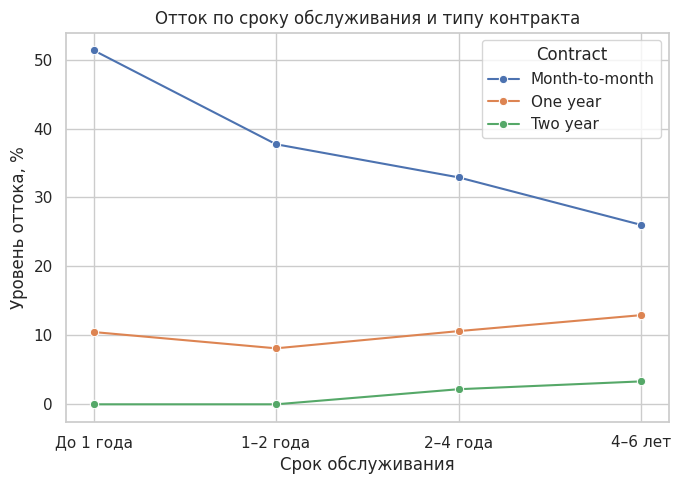

In [43]:
plt.figure(figsize=(7, 5))

ax = sns.lineplot(
    data=tenure_contract_churn,
    x='tenure_group',
    y='churn_rate',
    hue='Contract',
    marker='o'
)

ax.set_title('Отток по сроку обслуживания и типу контракта')
ax.set_xlabel('Срок обслуживания')
ax.set_ylabel('Уровень оттока, %')

plt.tight_layout()
plt.show()

Сочетание срока обслуживания и типа контракта позволяет увидеть более выраженные различия в уровне оттока.

Во всех группах по сроку обслуживания наиболее высокий уровень оттока наблюдается среди клиентов с контрактом Month-to-month. Даже среди клиентов со сроком обслуживания более четырёх лет показатель составляет **26,0%**.

Для клиентов с контрактом на один год уровень оттока находится в диапазоне **8,1–12,9%**, а для клиентов с контрактом на два года - не превышает **3,3%**.

Наиболее высокий показатель наблюдается среди клиентов со сроком обслуживания до года и контрактом Month-to-month — **51,4%**.

Таким образом, сочетание короткого срока обслуживания и контракта Month-to-month характеризуется особенно высоким уровнем оттока. При этом по имеющимся данным нельзя утверждать, что именно тип контракта или срок обслуживания являются причиной оттока.


# Тип контракта и тип интернет-подключения

Как уровень оттока различается в зависимости от типа контракта и интернет-подключения?

In [44]:
contract_internet_churn = (
    df.groupby(['Contract', 'InternetService'])['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='churn_rate')
)

contract_internet_churn

,Contract,InternetService,churn_rate
0,Month-to-month,DSL,32.215863
1,Month-to-month,Fiber optic,54.605263
2,Month-to-month,No,18.893130
3,One year,DSL,9.298246
4,One year,Fiber optic,19.294991
5,One year,No,2.472527
6,Two year,DSL,1.910828
7,Two year,Fiber optic,7.226107
8,Two year,No,0.783699


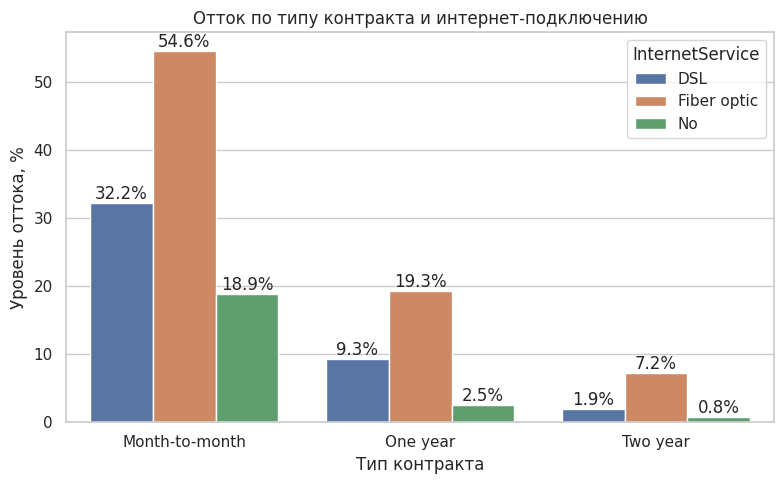

In [45]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=contract_internet_churn,
    x='Contract',
    y='churn_rate',
    hue='InternetService'
)

ax.set_title('Отток по типу контракта и интернет-подключению')
ax.set_xlabel('Тип контракта')
ax.set_ylabel('Уровень оттока, %')

for p in ax.patches:
    height = p.get_height()

    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

Совместный анализ типа контракта и интернет-подключения показывает заметные различия в уровне оттока.

Наиболее высокий уровень оттока наблюдается среди клиентов с контрактом Month-to-month и подключением Fiber optic - **54,6%**.

Для клиентов с контрактом Month-to-month и DSL уровень оттока составляет **32,2%**, а среди клиентов без интернета - **18,9%**.

При более длительных контрактах уровень оттока ниже независимо от типа интернет-подключения. Для контрактов на один год он составляет **2,5-19,3%**, а для контрактов на два года - **0,8-7,2%**.

Таким образом, особенно высокий уровень оттока наблюдается у сочетания **Month-to-month и Fiber optic**. Это позволяет выделить данную группу для дальнейшего анализа и потенциальных мер по удержанию клиентов.

При этом результаты показывают связь между характеристиками клиентов и оттоком, но не доказывают причинно-следственную зависимость.


# Выводы и рекомендации

В результате анализа были выявлены несколько характеристик и групп клиентов, связанных с повышенным уровнем оттока.

1. **Срок обслуживания** имеет выраженную связь с оттоком. Среди клиентов со сроком обслуживания до года уровень оттока составляет **47,4%**, тогда как среди клиентов со сроком более четырёх лет - **9,5%**.

2. **Тип контракта** также существенно различается между группами клиентов. Уровень оттока среди клиентов с контрактом Month-to-month составляет **42,7%**, с контрактом на один год - **11,3%**, на два года - **2,8%**.

3. **Тип интернет-подключения** связан с различиями в уровне оттока. Наиболее высокий показатель наблюдается у клиентов с Fiber optic - **41,9%**, против **19,0%** для DSL и **7,4%** среди клиентов без интернета.

4. Среди клиентов с интернетом заметные различия наблюдаются для **дополнительных услуг**. Например, уровень оттока составляет **41,8%** среди клиентов без `OnlineSecurity` и **14,6%** среди клиентов с этой услугой. Для `TechSupport` показатели составляют **41,6%** и **15,2%** соответственно.

5. У **ушедших клиентов выше ежемесячная плата**: среднее значение составляет **74,44** против **61,27** у оставшихся клиентов.

6. При совместном анализе характеристик особенно выделяется группа клиентов с **контрактом Month-to-month и Fiber optic**. Уровень оттока в этой группе составляет **54,6%**.

7. Также высокий показатель наблюдается среди клиентов со **сроком обслуживания до года и контрактом Month-to-month - 51,4%**.

Для основных выявленных различий были проведены статистические проверки. Полученные результаты подтверждают статистическую значимость связи между оттоком и такими признаками, как тип контракта, тип интернет-подключения, наличие `OnlineSecurity`, ежемесячная плата и срок обслуживания.

При этом анализ основан на наблюдаемых данных и не позволяет установить причинно-следственные связи. Выявленные характеристики следует рассматривать как признаки групп с различным уровнем оттока, а не как доказанные причины ухода клиентов.


## Практические рекомендации

На основе результатов анализа можно предложить следующие направления для дальнейшей работы с клиентским оттоком.

**1. Уделить особое внимание новым клиентам (0-12 месяцев)**

В этой группе отток 47,4%. Запустить усиленный онбординг в первые 3-6 месяцев: проверки качества, персональные предложения, контроль первых обращений в поддержку.

**2. Протестировать предложения по переходу на долгосрочный контракт среди клиентов с высоким риском оттока**

Клиенты с ежемесячной оплатой уходят в 42,7% случаев, а клиенты с двухгодовыми контрактами - 2,8% . Протестировать стимулирующие предложения (скидка / дополнительные услуги) за переход на 1-2 года и оценить эффект по результатам эксперимента.

**3. Приоритетный сегмент: Month-to-month + Fiber optic**

Отток в этой группе - 54,6%. Сделать отдельную программу удержания: пакет с OnlineSecurity + TechSupport + предложение смены контракта.

**4. Проверить эффективность предложения OnlineSecurity и TechSupport для групп с повышенным риском оттока**

У клиентов с этими услугами отток значительно ниже. Протестировать их включение в пакеты для клиентов с Fiber optic и высоким MonthlyCharges.

**5. Работа с клиентами, у которых выше MonthlyCharges**

У ушедших клиентов выше средняя ежемесячная плата. Проверить, не переплачивают ли они за неиспользуемые услуги, и предложить другие тарифы.

**6. Исследовать причины высокого churn среди клиентов, использующих Electronic check, с учётом типа контракта, tenure и других характеристик.**

## Ограничения анализа

При интерпретации результатов необходимо учитывать следующие ограничения:

1. **Наблюдательные данные не позволяют установить причинно-следственные связи.**
   Выявленные статистически значимые связи показывают, какие характеристики связаны с более высоким уровнем оттока, но не доказывают, что именно эти характеристики являются причиной ухода клиентов.

2. **Анализ не учитывает все возможные характеристики клиентов.**
   В датасете отсутствует часть информации, которая потенциально может быть связана с оттоком: история обращений в поддержку, жалобы, изменения тарифов, скидки, качество обслуживания и другие данные о взаимодействии с компанией.

3. **Некоторые признаки связаны между собой.**
   Например, срок обслуживания и общая сумма платежей закономерно связаны между собой. Поэтому нельзя рассматривать каждый признак полностью независимо от остальных.

4. **Результаты основаны на одном датасете.**
   Поэтому полученные закономерности нельзя автоматически переносить на другую телекоммуникационную компанию или другой период без дополнительной проверки.

5. **Статистическая значимость не означает практическую значимость.**
   При большом количестве клиентов даже небольшие различия могут оказаться статистически значимыми. Поэтому при принятии бизнес-решений необходимо учитывать не только p-value, но и размер различий, количество клиентов в группе и экономический эффект возможных действий.


# SQL - анализ

Для дополнительного анализа данных использован SQL. Запросы выполняются с помощью DuckDB непосредственно над DataFrame.

In [46]:
!pip install -q duckdb

In [47]:
import duckdb

con = duckdb.connect()
con.register('telco', df)

## 1. Общий уровень оттока

Определим количество клиентов и долю ушедших клиентов.

In [51]:
result = con.sql("""
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate
FROM telco;
""")

result.show()

┌─────────────────┬───────────────────┬────────────┐
│ total_customers │ churned_customers │ churn_rate │
│      int64      │      int128       │   double   │
├─────────────────┼───────────────────┼────────────┤
│            7043 │              1869 │       26.5 │
└─────────────────┴───────────────────┴────────────┘



SQL-проверка подтверждает общий уровень оттока клиентов, рассчитанный в ходе основного анализа.

## 2. Отток по типу контракта

Сравним уровень оттока клиентов в зависимости от типа контракта.

In [52]:
result = con.sql("""
SELECT
    Contract,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate
FROM telco
GROUP BY Contract
ORDER BY churn_rate DESC;
""")

result.show()

┌────────────────┬───────────┬───────────────────┬────────────┐
│    Contract    │ customers │ churned_customers │ churn_rate │
│    varchar     │   int64   │      int128       │   double   │
├────────────────┼───────────┼───────────────────┼────────────┤
│ Month-to-month │      3875 │              1655 │       42.7 │
│ One year       │      1473 │               166 │       11.3 │
│ Two year       │      1695 │                48 │        2.8 │
└────────────────┴───────────┴───────────────────┴────────────┘



Наибольший уровень оттока наблюдается среди клиентов с контрактом Month-to-month, а у клиентов с долгосрочными контрактами отток значительно ниже.

## 3. Отток по типу интернет-услуг

Проверим, различается ли уровень оттока в зависимости от типа интернет-услуг.

In [54]:
result = con.sql("""
SELECT
    InternetService,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate
FROM telco
GROUP BY InternetService
ORDER BY churn_rate DESC;
""")

result.show()

┌─────────────────┬───────────┬───────────────────┬────────────┐
│ InternetService │ customers │ churned_customers │ churn_rate │
│     varchar     │   int64   │      int128       │   double   │
├─────────────────┼───────────┼───────────────────┼────────────┤
│ Fiber optic     │      3096 │              1297 │       41.9 │
│ DSL             │      2421 │               459 │       19.0 │
│ No              │      1526 │               113 │        7.4 │
└─────────────────┴───────────┴───────────────────┴────────────┘



У клиентов с Fiber optic более высокий уровень оттока по сравнению с другими группами.

## 4. Отток в зависимости от срока обслуживания

Разделим клиентов на группы по длительности обслуживания и сравним уровень оттока.

In [58]:
result = con.sql("""
SELECT
    tenure_group,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate
FROM telco
GROUP BY tenure_group
ORDER BY tenure_group;
""")

result.show()

┌──────────────────────────────────────────────────────┬───────────┬───────────────────┬────────────┐
│                     tenure_group                     │ customers │ churned_customers │ churn_rate │
│ enum('До 1 года', '1–2 года', '2–4 года', '4–6 лет') │   int64   │      int128       │   double   │
├──────────────────────────────────────────────────────┼───────────┼───────────────────┼────────────┤
│ До 1 года                                            │      2186 │              1037 │       47.4 │
│ 1–2 года                                             │      1024 │               294 │       28.7 │
│ 2–4 года                                             │      1594 │               325 │       20.4 │
│ 4–6 лет                                              │      2239 │               213 │        9.5 │
└──────────────────────────────────────────────────────┴───────────┴───────────────────┴────────────┘



Наиболее высокий уровень оттока наблюдается среди клиентов с небольшим сроком обслуживания. По мере увеличения срока обслуживания доля ушедших клиентов снижается.

## 5. Поиск проблемных сегментов

Проверим комбинации типа контракта и интернет-услуг, чтобы определить сегменты с наиболее высоким уровнем оттока.

Из анализа исключены слишком маленькие группы (`< 100 клиентов`), чтобы отдельные наблюдения не искажали сравнение.

In [60]:
result = con.sql("""
SELECT
    InternetService,
    Contract,
    COUNT(*) AS customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS churn_rate
FROM telco
GROUP BY InternetService, Contract
HAVING COUNT(*) >= 100
ORDER BY churn_rate DESC;
""")

result.show()

┌─────────────────┬────────────────┬───────────┬───────────────────┬────────────┐
│ InternetService │    Contract    │ customers │ churned_customers │ churn_rate │
│     varchar     │    varchar     │   int64   │      int128       │   double   │
├─────────────────┼────────────────┼───────────┼───────────────────┼────────────┤
│ Fiber optic     │ Month-to-month │      2128 │              1162 │       54.6 │
│ DSL             │ Month-to-month │      1223 │               394 │       32.2 │
│ Fiber optic     │ One year       │       539 │               104 │       19.3 │
│ No              │ Month-to-month │       524 │                99 │       18.9 │
│ DSL             │ One year       │       570 │                53 │        9.3 │
│ Fiber optic     │ Two year       │       429 │                31 │        7.2 │
│ No              │ One year       │       364 │                 9 │        2.5 │
│ DSL             │ Two year       │       628 │                12 │        1.9 │
│ No            

Сочетание типа контракта и интернет-услуг позволяет выделить клиентские сегменты с повышенным уровнем оттока. Полученные сегменты можно использовать для дальнейшего исследования причин churn и проверки гипотез по удержанию клиентов.

В рамках проекта проведён анализ оттока клиентов телеком-компании: выполнена очистка данных, разведочный анализ, статистическая проверка гипотез, анализ сочетаний признаков и SQL-анализ ключевых показателей.
Наиболее сильная связь с оттоком наблюдается у типа контракта, срока обслуживания, типа интернет-подключения и отсутствия услуг OnlineSecurity / TechSupport. Выделены сегменты повышенного риска, которые могут стать основой для дальнейших гипотез и программ удержания.